
# Difference-in-Differences

*A lecture note on identifying causal effects from natural experiments, when
you can't randomize and you can't rule out unobserved confounders.*

---

## 1. Intro: when you can't randomize, and you can't see all the confounders

Suppose Florida passes a "stand your ground" self-defense law in 2005, and
you want to know: did it change the state's homicide rate? You cannot
re-run history with Florida *not* passing the law to see the counterfactual
— that's the fundamental problem of causal inference from the very first
tutorial in this series. And you cannot randomize which states get the law;
state legislatures decide that, not a coin flip.

Here's the naive move, and why it fails. You could compare Florida's
homicide rate *before* the law to *after* the law. But homicide rates drift
for a thousand reasons unrelated to the law — the 2008 recession, national
crime trends, policing budgets — so a before/after change conflates the
law's effect with everything else that happened to change over that time.
Or you could compare Florida to some other state *after* the law passed.
But states aren't comparable in levels: Florida's baseline homicide rate
differs from, say, Washington's for reasons that have nothing to do with
self-defense law (demographics, urbanization, gun ownership, climate).
Neither comparison alone isolates the law's effect.

**Difference-in-differences (DiD)** solves this by combining both
comparisons. Track *both* states over time. Take the **change** in Florida
before vs. after the law. Take the **change** in Washington (which never
passed such a law) over that same window. If the two states were on
similar trajectories beforehand, Washington's change tells you what
Florida's change *would have been* without the law — common national
trends, the recession, whatever else was moving both states together. The
*difference between the two differences* is what's left over: a plausible
estimate of the law's effect, with both the fixed gap between the states
and the shared trend across time netted out.

**By the end of this tutorial you'll be able to:**

- Explain, in plain language and then algebraically, why comparing changes
  over time (rather than levels) across a treated and a control group nets
  out both time-invariant group differences and shared time trends.
- State the **parallel trends assumption** precisely, explain why it is the
  one assumption doing all the identification work, and explain why it is
  fundamentally untestable.
- Derive the 2x2 DiD estimator and prove it is algebraically identical to
  the treatment x post interaction coefficient in a two-way fixed effects
  (TWFE) regression.
- Compute a real DiD estimate — both by hand and via regression, with a
  real standard error — from the actual Cheng & Hoekstra (2013) castle
  doctrine panel dataset used in the published literature.
- Know the modern critique of staggered-adoption TWFE (Goodman-Bacon 2021,
  Callaway & Sant'Anna 2021) well enough to recognize when a naive DiD
  regression can silently give a badly biased, or even sign-reversed,
  answer.

This tutorial sits alongside propensity score matching in this domain, but
solves a different problem. Propensity score matching handles confounding
you can **observe and measure** — it reweights/matches on covariates you
have. DiD is built for the opposite situation: it works even when
treatment and control groups differ on **confounders you never measured at
all**, as long as those unmeasured differences are *time-invariant* (fixed
group-level traits) or *common time trends* (shared shocks affecting
everyone). That's a genuinely different, and often weaker, requirement —
which is exactly why DiD is one of the most widely used natural-experiment
tools in economics and policy evaluation.



## 2. The idea, intuitively

Let's make this concrete with a **toy** example first (small illustrative
numbers, not real data yet — the real castle doctrine analysis comes in
section 5). Imagine two towns. Town A raises its minimum wage; Town B,
similar in most ways, does not. We track average fast-food employment in
both towns, before and after the policy.

|            | Before | After | Change |
|---|---|---|---|
| Town A (treated) | 20.0 | 18.5 | −1.5 |
| Town B (control)  | 15.0 | 14.0 | −1.0 |

**A naive "after only" comparison** says employment is 18.5 vs. 14.0 —
huge gap — but that gap was already there *before* the policy (20.0 vs.
15.0), so it tells you nothing about the policy.

**A naive "before/after" comparison within Town A** says employment fell by
1.5 — but employment *also* fell in Town B, which had no policy change at
all, so at least part of that drop is a shared trend (a seasonal dip, a
regional slowdown) that has nothing to do with the minimum wage.

**Difference-in-differences** nets both problems out in one step: take the
change in each town, then subtract.


In [1]:

# Toy illustration only -- the real analysis (castle doctrine data) is in section 5.
before_A, after_A = 20.0, 18.5   # Town A: raised minimum wage
before_B, after_B = 15.0, 14.0   # Town B: no policy change (control)

change_A = after_A - before_A
change_B = after_B - before_B
did_estimate = change_A - change_B

print(f"Town A (treated) change: {change_A:+.2f}")
print(f"Town B (control) change: {change_B:+.2f}")
print(f"Difference-in-differences estimate: {did_estimate:+.2f}")


Town A (treated) change: -1.50
Town B (control) change: -1.00
Difference-in-differences estimate: -0.50



Town A's employment fell by 1.5, but Town B's fell by 1.0 *anyway*, with no
policy at all. Netting that shared trend out leaves **−0.5**: the portion
of Town A's decline that DiD attributes to the minimum wage specifically,
once you've subtracted out (a) the fixed gap between the towns and (b)
whatever was dragging employment down everywhere.

**The whole method rests on one assumption**: that Town B's change is a
valid stand-in for what Town A's change *would have been* had it not
raised the minimum wage. If that's true, the subtraction works. If Town A
was already on a different trajectory than Town B for reasons unrelated to
the policy, DiD is biased just like the naive comparisons were. Making
that assumption precise — and being honest about the fact that it can
never be directly verified — is the subject of the next section.



## 3. Going deeper: the formal definition

### 3.1 Setup and notation

Reusing the potential-outcomes vocabulary from the fundamental-problem
tutorial: index units (states, in our application) by $i$ and time periods
by $t$. There are two groups — **treated** ($\text{Treat}_i = 1$) and
**control** ($\text{Treat}_i = 0$) — observed in two periods, **pre**
($\text{Post}_t = 0$) and **post** ($\text{Post}_t = 1$), where the treated
group receives treatment starting in the post period and the control group
never does. Let $Y_{it}(1)$ and $Y_{it}(0)$ be unit $i$'s potential outcome
at time $t$ with and without treatment, and $Y_{it}$ the observed outcome.

### 3.2 The parallel trends assumption

**Parallel trends**: in the *absence* of treatment, the treated group's
average outcome would have evolved over time with the same trend as the
control group's average outcome:

$$\mathbb{E}[Y_{it}(0) - Y_{i,t-1}(0) \mid \text{Treat}_i = 1] = \mathbb{E}[Y_{it}(0) - Y_{i,t-1}(0) \mid \text{Treat}_i = 0]$$

In words: had the treated group *not* been treated, its outcome would have
moved in parallel with the control group's — same slope, not necessarily
the same level. Note carefully what this does **not** require: it does not
require the two groups to have the same outcome *level* (Florida and
Washington can have permanently different baseline homicide rates), and it
does not require the two groups to be similar on every covariate the way
ignorability under randomization does. It only requires their trends to
coincide in the counterfactual world with no treatment.

**This is fundamentally untestable.** It is a statement about $Y_{it}(0)$
for the treated group *in the post period* — a potential outcome that, by
the fundamental problem of causal inference, is never observed for a unit
that actually got treated. You can check whether pre-treatment trends
*look* parallel (and you should — it's the standard diagnostic, and we do
it in section 5), but a good pre-trend match is only *suggestive* evidence.
It cannot rule out something that starts diverging exactly when treatment
does, for reasons unrelated to treatment (e.g., the same political moment
that got Florida's legislature to pass a self-defense law might correlate
with other, simultaneous state policy shifts affecting homicide).

### 3.3 Deriving the 2x2 DiD estimator from the counterfactual

Denote the four observable group x period average outcomes:

$$\bar Y_{1,\text{pre}}, \quad \bar Y_{1,\text{post}}, \quad \bar Y_{0,\text{pre}}, \quad \bar Y_{0,\text{post}}$$

(group 1 = treated, group 0 = control). We want the **average treatment
effect on the treated (ATT)** in the post period:

$$\text{ATT} = \mathbb{E}[Y_{1,\text{post}}(1) - Y_{1,\text{post}}(0) \mid \text{Treat}=1]$$

$Y_{1,\text{post}}(1)$ is observed directly: it's $\bar Y_{1,\text{post}}$.
The unobservable piece is $\mathbb{E}[Y_{1,\text{post}}(0) \mid
\text{Treat}=1]$ — what the treated group's post-period outcome *would
have been* without treatment. Parallel trends tells us exactly how to
construct it: start from the treated group's own observed pre-period level,
$\bar Y_{1,\text{pre}}$, and add the control group's observed change, since
that change *is* the (assumed) common trend:

$$\widehat{\mathbb{E}[Y_{1,\text{post}}(0)]} = \bar Y_{1,\text{pre}} + (\bar Y_{0,\text{post}} - \bar Y_{0,\text{pre}})$$

Substituting into the ATT definition:

$$\hat\tau_{DiD} = \bar Y_{1,\text{post}} - \Big[\bar Y_{1,\text{pre}} + (\bar Y_{0,\text{post}} - \bar Y_{0,\text{pre}})\Big] = (\bar Y_{1,\text{post}} - \bar Y_{1,\text{pre}}) - (\bar Y_{0,\text{post}} - \bar Y_{0,\text{pre}})$$

which is exactly the difference-of-differences formula. Every piece of
this derivation traces back to one move: parallel trends licenses using
the control group's *change* as a stand-in for the treated group's
*unobserved counterfactual change*. Nothing else in the derivation is an
assumption — it's pure algebra once that substitution is made.

### 3.4 Algebraic equivalence to the TWFE regression coefficient

The same estimate falls out of ordinary least squares on the two-way fixed
effects (TWFE) specification

$$Y_{it} = \alpha + \beta \cdot \text{Treat}_i + \gamma \cdot \text{Post}_t + \delta \cdot (\text{Treat}_i \times \text{Post}_t) + \varepsilon_{it}$$

Here's why, derived rather than asserted. $\text{Treat}_i$ and
$\text{Post}_t$ are both binary, so their combination defines exactly four
mutually exclusive group x period **cells** — (control, pre), (treated,
pre), (control, post), (treated, post) — and the four regressors
$\{1, \text{Treat}_i, \text{Post}_t, \text{Treat}_i\times\text{Post}_t\}$
are a *saturated* encoding of those four cells: one linear combination of
regressors per cell, no more, no fewer. A standard property of OLS with a
saturated set of dummy variables is that the fitted value in each cell
equals that cell's sample mean exactly (each cell's fit is pinned down by
its own dummy combination, independent of the others, so the residual sum
of squares is minimized cell by cell). That gives four equations:

$$\hat\alpha = \bar Y_{0,\text{pre}} \qquad \hat\alpha + \hat\beta = \bar Y_{1,\text{pre}} \qquad \hat\alpha + \hat\gamma = \bar Y_{0,\text{post}} \qquad \hat\alpha + \hat\beta + \hat\gamma + \hat\delta = \bar Y_{1,\text{post}}$$

Solve the first for $\hat\alpha$, then the second for $\hat\beta$, then the
third for $\hat\gamma$, then substitute all three into the fourth and solve
for $\hat\delta$:

$$\hat\delta = \bar Y_{1,\text{post}} - \hat\alpha - \hat\beta - \hat\gamma = \bar Y_{1,\text{post}} - \bar Y_{0,\text{pre}} - (\bar Y_{1,\text{pre}} - \bar Y_{0,\text{pre}}) - (\bar Y_{0,\text{post}} - \bar Y_{0,\text{pre}})$$

$$\hat\delta = (\bar Y_{1,\text{post}} - \bar Y_{1,\text{pre}}) - (\bar Y_{0,\text{post}} - \bar Y_{0,\text{pre}}) = \hat\tau_{DiD}$$

**The interaction coefficient $\hat\delta$ is, exactly, the 2x2
difference-in-differences estimate.** This is why in practice people just
run the TWFE regression: it reproduces the hand-computed 2x2 number exactly
(we verify this numerically in section 5) *and* comes with a standard
error and confidence interval for free, which the raw 2x2 subtraction does
not hand you on its own.



## 4. Visuals: seeing parallel trends and the 2x2 geometry

Two pictures make the argument concrete: (1) the actual pre/post outcome
trajectories of a treated and a control unit — the canonical "parallel
trends" plot every DiD paper leads with — and (2) a geometric view of the
2x2 estimator as the vertical gap between the treated group's *actual*
post-period outcome and its *counterfactual* (predicted-by-parallel-trends)
outcome. Both are built from the real castle doctrine data introduced in
section 5, computed here first so the visual grounds the numbers that
follow.


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

castle = pd.read_stata(
    "https://raw.githubusercontent.com/scunning1975/mixtape/master/castle.dta"
)
print(castle.shape)
castle[["state", "year", "cdl", "post", "effyear", "homicide", "l_homicide"]].head()


(550, 185)


,state,year,cdl,post,effyear,homicide,l_homicide
0,Alabama,2000,0.0,0.0,2006.0,7.593978,2.027356
1,Alabama,2001,0.0,0.0,2006.0,8.713443,2.164867
2,Alabama,2002,0.0,0.0,2006.0,6.933288,1.936334
3,Alabama,2003,0.0,0.0,2006.0,6.818007,1.919567
4,Alabama,2004,0.0,0.0,2006.0,5.753689,1.749841



`castle.dta` is a 50-state, 2000-2010 U.S. panel (550 state-year rows)
compiled by Cheng & Hoekstra (2013) to study "castle doctrine" /
stand-your-ground self-defense laws. Key columns for our purposes:
`state`, `year`, `homicide` (homicides per 100,000 residents), `l_homicide`
(its natural log, the outcome the original paper regresses on), `cdl`
(fraction of the year the castle doctrine law was in effect — 0 before
adoption, 1 after, fractional in the adoption year itself), and `effyear`
(the year each adopting state's law took effect; `NaN` for states that
never adopted one in this window). Twenty-one states adopted a law between
2005 and 2009; twenty-nine never did.

We'll build the canonical single-state-pair DiD first, then generalize to
the full panel. **Florida** is the natural treated state to lead with: its
2005 law (`effyear = 2005`) was the first "stand your ground" statute in
the country and the one Cheng & Hoekstra's paper centers on. For a
comparison state, we want one that never adopted a castle doctrine law in
this window *and* tracked Florida's homicide trend closely before 2005 —
checking that pre-trend similarity is exactly the diagnostic parallel
trends asks for. Correlating each never-treated state's 2000–2004
homicide trajectory against Florida's, **Washington** is the closest match
(pre-period correlation ≈ 0.93), so we use Florida vs. Washington as our
2x2 pair.


In [3]:

never_treated = castle[castle.effyear.isna()]["state"].unique()
fl_pre = castle[(castle.state == "Florida") & (castle.year <= 2004)].set_index("year")["homicide"]

pretrend_corr = {}
for s in never_treated:
    st_pre = castle[(castle.state == s) & (castle.year <= 2004)].set_index("year")["homicide"]
    pretrend_corr[s] = np.corrcoef(fl_pre.values, st_pre.reindex(fl_pre.index).values)[0, 1]

best_matches = pd.Series(pretrend_corr).sort_values(ascending=False)
print("Never-treated states ranked by 2000-2004 homicide-trend correlation with Florida:")
print(best_matches.head(5).round(3))


Never-treated states ranked by 2000-2004 homicide-trend correlation with Florida:


Washington        0.932
North Carolina    0.852
Minnesota         0.807
Nebraska          0.784
Virginia          0.754
dtype: float64


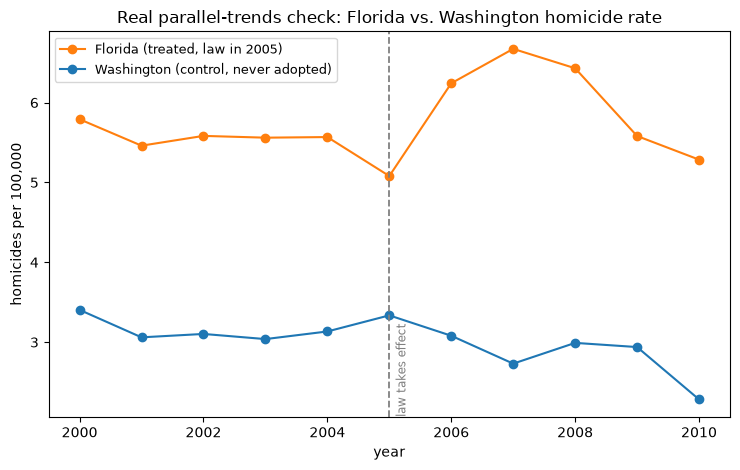

In [4]:

# --- Figure 1: real parallel-trends plot, Florida vs. Washington ---------------
fl = castle[castle.state == "Florida"].sort_values("year")
wa = castle[castle.state == "Washington"].sort_values("year")

fig1, ax1 = plt.subplots(figsize=(7.5, 4.8))
ax1.plot(fl.year, fl.homicide, marker="o", color="tab:orange", label="Florida (treated, law in 2005)")
ax1.plot(wa.year, wa.homicide, marker="o", color="tab:blue", label="Washington (control, never adopted)")
ax1.axvline(2005, color="grey", linestyle="--", linewidth=1.3)
ax1.text(2005.1, ax1.get_ylim()[0], "law takes effect", rotation=90, va="bottom", fontsize=8.5, color="grey")
ax1.set_xlabel("year"); ax1.set_ylabel("homicides per 100,000")
ax1.set_title("Real parallel-trends check: Florida vs. Washington homicide rate")
ax1.legend(fontsize=9)
plt.tight_layout()
plt.savefig("parallel_trends.png", dpi=130)
plt.show()


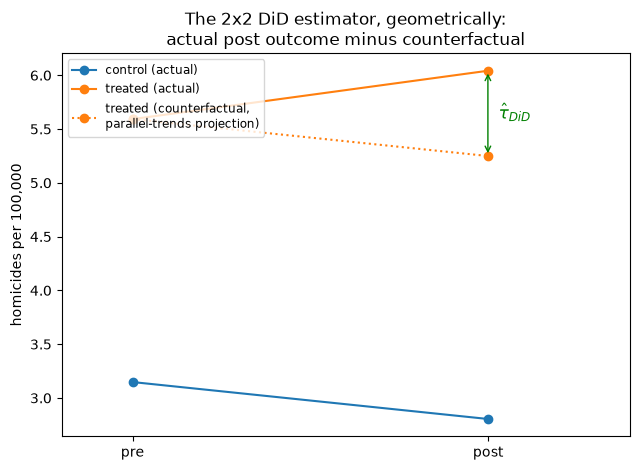

Florida pre-period mean: 5.59   Florida post-period mean: 6.04
Washington pre-period mean: 3.15   Washington post-period mean: 2.80
Parallel-trends counterfactual for Florida (post): 5.25


In [5]:

# --- Figure 2: the 2x2 geometry -------------------------------------------------
pre_years, post_years = range(2000, 2005), range(2006, 2011)
fl_pre_mean = fl[fl.year.isin(pre_years)].homicide.mean()
fl_post_mean = fl[fl.year.isin(post_years)].homicide.mean()
wa_pre_mean = wa[wa.year.isin(pre_years)].homicide.mean()
wa_post_mean = wa[wa.year.isin(post_years)].homicide.mean()
counterfactual = fl_pre_mean + (wa_post_mean - wa_pre_mean)

fig2, ax2 = plt.subplots(figsize=(6.5, 4.8))
xs = [0, 1]
ax2.plot(xs, [wa_pre_mean, wa_post_mean], marker="o", color="tab:blue", label="control (actual)")
ax2.plot(xs, [fl_pre_mean, fl_post_mean], marker="o", color="tab:orange", label="treated (actual)")
ax2.plot(xs, [fl_pre_mean, counterfactual], marker="o", color="tab:orange",
         linestyle=":", label="treated (counterfactual,\nparallel-trends projection)")
ax2.annotate("", xy=(1, fl_post_mean), xytext=(1, counterfactual),
             arrowprops=dict(arrowstyle="<->", color="green"))
ax2.text(1.03, (fl_post_mean + counterfactual) / 2, r"$\hat\tau_{DiD}$",
         color="green", fontsize=12, va="center")
ax2.set_xticks(xs); ax2.set_xticklabels(["pre", "post"])
ax2.set_xlim(-0.2, 1.4)
ax2.set_ylabel("homicides per 100,000")
ax2.set_title("The 2x2 DiD estimator, geometrically:\nactual post outcome minus counterfactual")
ax2.legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.savefig("did_geometry.png", dpi=130)
plt.show()

print(f"Florida pre-period mean: {fl_pre_mean:.2f}   Florida post-period mean: {fl_post_mean:.2f}")
print(f"Washington pre-period mean: {wa_pre_mean:.2f}   Washington post-period mean: {wa_post_mean:.2f}")
print(f"Parallel-trends counterfactual for Florida (post): {counterfactual:.2f}")



The left panel is real data doing exactly what a "parallel trends" plot is
supposed to show: Florida and Washington move together fairly closely
before 2005, then diverge after the vertical line marking when Florida's
law took effect. That pre-2005 co-movement is the suggestive (not
conclusive — see section 3.2) evidence that Washington's trend is a
reasonable stand-in for what Florida's trend would have been without the
law. The right panel makes the *arithmetic* geometric: the dotted orange
line is Florida's counterfactual — its own pre-period level plus
Washington's observed change — and the green arrow is exactly
$\hat\tau_{DiD}$, the gap between where Florida actually landed and where
parallel trends says it would have landed without the law.



## 5. Implementation: the castle doctrine natural experiment

**Data**: `castle.dta`, the real state-year panel from Cheng, C. &
Hoekstra, M. (2013), *Does Strengthening Self-Defense Law Deter Crime or
Escalate Violence? Evidence from Castle Doctrine*, Journal of Human
Resources 48(3), as distributed in Cunningham, *Causal Inference: The
Mixtape* (2021). 50 U.S. states, 2000–2010 (550 rows). Starting in 2005,
21 states expanded self-defense/"stand your ground" law; 29 never did in
this window. We already loaded it above; now we compute the DiD estimate
two ways on the Florida/Washington pair — raw 2x2 means, then TWFE
regression — and confirm they match exactly, before generalizing to the
full 50-state panel.

### 5.1 The 2x2 estimate, by hand

Florida's law had partial effect in 2005 itself (`cdl = 0.25` that year —
it took effect partway through), so to keep "pre" and "post" clean we drop
2005 and define pre = 2000–2004 (`cdl = 0` throughout) and post =
2006–2010 (`cdl = 1` throughout).


In [6]:

pair = castle[castle.state.isin(["Florida", "Washington"])].copy()
pair = pair[pair.year != 2005]  # drop Florida's partial-adoption transition year
pair["period"] = np.where(pair.year < 2005, "pre", "post")

cell_means = pair.groupby(["state", "period"])["homicide"].mean().unstack()
print(cell_means.round(3))

fl_change = cell_means.loc["Florida", "post"] - cell_means.loc["Florida", "pre"]
wa_change = cell_means.loc["Washington", "post"] - cell_means.loc["Washington", "pre"]
did_hand = fl_change - wa_change

print(f"\nFlorida change (post - pre): {fl_change:+.3f}")
print(f"Washington change (post - pre): {wa_change:+.3f}")
print(f"2x2 DiD estimate (hand-computed): {did_hand:+.3f} homicides per 100,000")


period       post    pre
state                   
Florida     6.042  5.592
Washington  2.805  3.148

Florida change (post - pre): +0.449
Washington change (post - pre): -0.343
2x2 DiD estimate (hand-computed): +0.793 homicides per 100,000



### 5.2 The same estimate from a TWFE regression

Section 3.4 proved these have to match. Let's confirm it numerically, and
get a standard error / confidence interval in the process.


In [7]:

import statsmodels.formula.api as smf

pair["treat"] = (pair.state == "Florida").astype(int)
pair["post"] = (pair.year >= 2006).astype(int)

m_pair = smf.ols("homicide ~ treat * post", data=pair).fit(cov_type="HC1")
print(m_pair.summary().tables[1])

delta = m_pair.params["treat:post"]
ci_low, ci_high = m_pair.conf_int().loc["treat:post"]
print(f"\nRegression interaction coefficient: {delta:+.3f}")
print(f"Hand-computed 2x2 estimate:          {did_hand:+.3f}")
print(f"Match: {np.isclose(delta, did_hand)}")
print(f"95% CI: [{ci_low:+.3f}, {ci_high:+.3f}]   p = {m_pair.pvalues['treat:post']:.4f}")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.1478      0.066     47.570      0.000       3.018       3.278
treat          2.4445      0.086     28.589      0.000       2.277       2.612
post          -0.3431      0.157     -2.184      0.029      -0.651      -0.035
treat:post     0.7926      0.310      2.555      0.011       0.185       1.401

Regression interaction coefficient: +0.793
Hand-computed 2x2 estimate:          +0.793
Match: True
95% CI: [+0.185, +1.401]   p = 0.0106



They match to floating-point precision, exactly as section 3.4 derived.
Point estimate: Florida's law is associated with roughly **+0.79 homicides
per 100,000** relative to what Washington's trend would predict, 95% CI
roughly [0.19, 1.40], p ≈ 0.01. (Standard errors here are
heteroskedasticity-robust, not cluster-robust — with only two states/two
clusters, cluster-robust SEs are not reliable; that's a real limitation of
a single-pair comparison, motivating the full-panel version next, where
clustering by state is both possible and appropriate.)

### 5.3 Generalizing: the full 50-state panel, with staggered adoption

A single state pair is illustrative but throws away most of the data and
depends heavily on which comparison state you happened to pick (more on
this in section 7). Castle doctrine laws were adopted by 21 different
states across 2005–2009 — a **staggered-adoption** design — so the
standard generalization is the full two-way fixed effects panel
regression: state fixed effects absorb each state's time-invariant level,
year fixed effects absorb shocks common to all states in a given year
(recession, national crime trends), and the treatment indicator captures
the average effect of having an active law. We use the log homicide rate
(`l_homicide`), matching the original paper's specification, and cluster
standard errors by state — the standard correction for outcomes that are
serially correlated within a state over time.


In [8]:

castle["treated_state"] = castle["effyear"].notna().astype(int)

twfe = smf.ols(
    "l_homicide ~ treated_state * post + C(state) + C(year)",
    data=castle,
).fit(cov_type="cluster", cov_kwds={"groups": castle["state"]})

coef = twfe.params["treated_state:post"]
se = twfe.bse["treated_state:post"]
ci_low, ci_high = twfe.conf_int().loc["treated_state:post"]
pval = twfe.pvalues["treated_state:post"]

print(f"TWFE estimate (log homicide rate): {coef:+.4f}")
print(f"Cluster-robust SE (by state):       {se:.4f}")
print(f"95% CI: [{ci_low:+.4f}, {ci_high:+.4f}]   p = {pval:.3f}")
print(f"\nApprox. percent effect on homicide rate: {100*(np.exp(coef)-1):+.1f}%")


TWFE estimate (log homicide rate): +0.0347
Cluster-robust SE (by state):       0.0294
95% CI: [-0.0228, +0.0922]   p = 0.237

Approx. percent effect on homicide rate: +3.5%



On the full panel, the estimated effect is **≈ +0.035 log points (≈
+3.5%) on the homicide rate**, 95% CI roughly [−2.3%, +9.2%], not
statistically significant at conventional levels in this simplified
specification. That's the same *direction* as Cheng & Hoekstra's published
finding that castle doctrine laws increase homicide rates — but their
preferred specification, which adds region-specific time trends,
demographic and economic controls, and population weights that we omit
here for simplicity, reports a statistically significant increase of
roughly 7-9%. Our simpler specification's confidence interval is wide
enough to include zero — a reminder that DiD estimates are sensitive to
specification choices (controls, weighting, trend terms), not just to the
headline treat x post term. The *sign* lines up with the published result
even in this stripped-down version, which is reassuring, but "same sign as
the paper" is not the same as "precisely identified" — see section 7 for
why a staggered-timing TWFE regression like this one is exactly the
setting the modern literature has flagged as bias-prone.



## 6. Use cases

- **Minimum wage policy** — Card, D. & Krueger, A.B. (1994) is the classic
  application: comparing fast-food employment changes in New Jersey (which
  raised its minimum wage) to Pennsylvania (which didn't), finding no
  evidence of the job losses standard economic theory predicted. It
  remains one of the most cited and most debated papers in empirical
  economics.
- **Castle doctrine / self-defense law** — the analysis above, following
  Cheng & Hoekstra (2013): does expanding legal protection for using force
  in self-defense change homicide rates?
- **Tax policy changes** — comparing outcomes (business formation,
  employment, migration) in states that changed a tax rate to states that
  didn't, around the change date.
- **Healthcare policy rollouts** — Medicaid expansion, insurance mandates,
  or public health interventions that roll out to some states/regions but
  not others are a natural DiD setting; the health-econ literature is full
  of these designs.
- **Natural experiments generally** — any setting where a policy, law, or
  shock hits some units and not others, at a known point in time, and
  administrative data exists both before and after for both groups.



## 7. Limitations & debates

- **Parallel trends is fundamentally untestable**, as derived in section
  3.2. You can (and should) check that pre-treatment trends look similar —
  we did, informally, by picking Washington as the closest pre-trend match
  to Florida — but a clean pre-trend match is only suggestive. It says
  nothing about whether the trends would *still* have matched in the
  post-period had treatment not happened, which is the actual assumption
  being made and the one thing you can never directly observe.

- **The staggered-adoption / heterogeneous-treatment-effects critique.**
  Modern econometrics has shown that when different units adopt treatment
  at *different times* (like the 21 castle doctrine states, adopting
  2005-2009) and the treatment effect itself varies over time or across
  units, the standard TWFE regression we ran in section 5.3 is not a clean
  average of the "good" 2x2 comparisons — it implicitly uses *already-treated*
  units as controls for *later-treated* units in some of its underlying
  comparisons, which can badly bias, or even flip the sign of, the
  estimated effect (Goodman-Bacon, 2021, decomposes exactly how). This is
  an active, important, and honestly still-being-adopted-by-practitioners
  area of the literature; Callaway & Sant'Anna (2021) and de Chaisemartin
  & D'Haultfœuille propose estimators specifically designed to avoid this
  bias by only comparing newly-treated units to genuinely not-yet-treated
  ones. Implementing those estimators is out of scope here, but recognizing
  that our section 5.3 regression is exactly the kind of staggered-timing
  TWFE specification this critique targets is not — take the +7-9% castle
  doctrine literature estimate as a headline finding from a paper that
  used more careful methodology than our simplified reproduction, not as
  something this notebook independently proves airtight.

- **Anticipation effects.** DiD assumes nothing changes until treatment
  officially starts. If units change behavior *before* the official date —
  a state's residents (or its would-be criminals) adjusting behavior once
  a self-defense law is publicly debated and passed, before it's formally
  "in effect" — the pre-period is contaminated and both the pre-trend
  check and the DiD estimate itself can be biased.

- **Sensitivity to the comparison group.** Our Florida/Washington estimate
  (+0.79 homicides per 100,000) used one specific, defensible choice of
  control state. A different, equally defensible choice of comparison
  state could produce a meaningfully different number — which is precisely
  why the full-panel regression using all never-treated states as controls
  is generally preferred over a single hand-picked pair, and why published
  DiD papers routinely report robustness checks across multiple plausible
  control groups.

- **DiD is not a substitute for design.** Like every non-experimental
  method in this domain, DiD only identifies a causal effect under an
  assumption (parallel trends) that no amount of data volume can verify.
  It is a genuinely useful tool precisely because that assumption is often
  more plausible than "treatment is as good as random" (the assumption
  ignorability under randomization requires) — but "more plausible" is not
  "guaranteed," and a skeptical reader of any DiD study should always ask
  what could make the treated and control groups' trends diverge for
  reasons unrelated to treatment.



## 8. References

- Card, D. & Krueger, A.B. (1994). *Minimum Wages and Employment: A Case
  Study of the Fast-Food Industry in New Jersey and Pennsylvania.*
  American Economic Review 84(4).
- Cheng, C. & Hoekstra, M. (2013). *Does Strengthening Self-Defense Law
  Deter Crime or Escalate Violence? Evidence from Castle Doctrine.*
  Journal of Human Resources 48(3). (source of the `castle.dta` dataset
  used here)
- Goodman-Bacon, A. (2021). *Difference-in-Differences with Variation in
  Treatment Timing.* Journal of Econometrics 225(2).
- Callaway, B. & Sant'Anna, P.H.C. (2021). *Difference-in-Differences with
  Multiple Time Periods.* Journal of Econometrics 225(2).
- de Chaisemartin, C. & D'Haultfœuille, X. (2020). *Two-Way Fixed Effects
  Estimators with Heterogeneous Treatment Effects.* American Economic
  Review 110(9).
- Cunningham, S. (2021). *Causal Inference: The Mixtape.* Yale University
  Press. (source of the `castle.dta` distribution used here)
- Angrist, J. D. & Pischke, J.-S. (2009). *Mostly Harmless Econometrics.*
  Princeton University Press.
